# Chapter 153 — Matrix Addition

> **Prerequisites:** Matrix representation *(ch152)*, vector addition *(ch125)*  
> **You will learn:**
> - Matrix addition as elementwise operation
> - Scalar multiplication of matrices
> - Broadcasting in NumPy
> - What matrix addition means geometrically (combining transformations)
>
> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

Matrix addition is the simplest matrix operation: add corresponding entries. Two matrices can be added only if they have the same shape.

This is structurally identical to vector addition *(ch125)* — a matrix is just a vector that happens to be arranged in two dimensions.

More importantly: **adding two transformation matrices gives a transformation that is the sum of the two transformations.** This is a direct consequence of linearity.

**Common misconceptions:**
- *"You can add any two matrices."* — Only if they have identical shape.
- *"Matrix addition and matrix multiplication are similar operations."* — They are not. Addition is elementwise and commutative; multiplication is not.

---

## 2. Intuition & Mental Models

**Geometric:** If A stretches the x-axis and B rotates, then A+B is a new transformation that does both effects simultaneously, applied to each basis vector independently. The output of (A+B)v equals Av + Bv — both transformations applied and summed.

**Computational:** Think of matrix addition as a vectorized for-loop over all entries. `C[i,j] = A[i,j] + B[i,j]` for every (i,j).

Recall from ch125 (Vector Addition) that adding vectors is tip-to-tail. Matrix addition is the same thing — but done simultaneously for every row of each matrix considered as a vector.

---

## 3. Visualization

Verifying (A+B)v = Av + Bv for all test vectors:
Max difference: 0.00e+00


C:\Users\user\AppData\Local\Temp\ipykernel_13560\2149386769.py:36: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_13560\2149386769.py:36: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


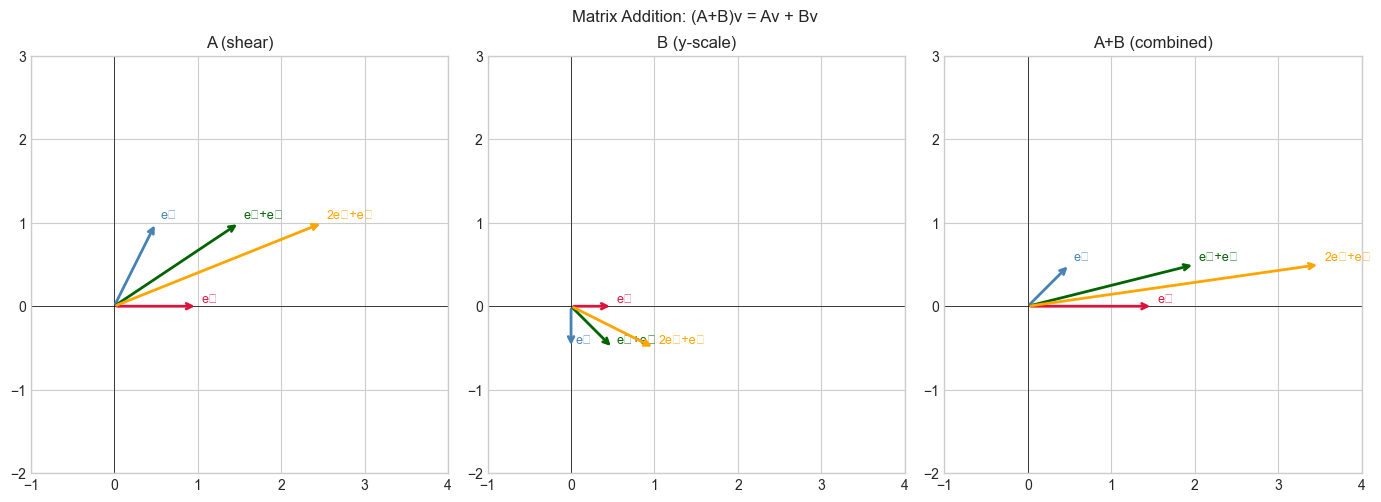

In [1]:
# --- Visualization: (A+B)v = Av + Bv ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

A = np.array([[1.0, 0.5], [0.0, 1.0]])   # shear
B = np.array([[0.5, 0.0], [0.0, -0.5]])  # scale y by -0.5
C = A + B

# Test vectors
vectors = np.array([[1,0],[0,1],[1,1],[2,1]], dtype=float).T  # 2x4

Av = A @ vectors
Bv = B @ vectors
Cv = C @ vectors
AvpBv = Av + Bv   # should equal Cv

print("Verifying (A+B)v = Av + Bv for all test vectors:")
print(f"Max difference: {np.max(np.abs(Cv - AvpBv)):.2e}")

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
colors = ['crimson','steelblue','darkgreen','orange']
labels = ['e₁','e₂','e₁+e₂','2e₁+e₂']

for ax, mat, title in zip(axes, [A, B, C], ['A (shear)', 'B (y-scale)', 'A+B (combined)']):
    result = mat @ vectors
    for k in range(vectors.shape[1]):
        ax.annotate('', xy=result[:,k], xytext=(0,0),
                    arrowprops=dict(arrowstyle='->', color=colors[k], lw=2))
        ax.text(result[0,k]+0.05, result[1,k]+0.05, labels[k], fontsize=9, color=colors[k])
    ax.set_xlim(-1, 4); ax.set_ylim(-2, 3); ax.set_aspect('equal')
    ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
    ax.set_title(title)

plt.suptitle('Matrix Addition: (A+B)v = Av + Bv', fontsize=12)
plt.tight_layout()
plt.show()

---

## 4. Mathematical Formulation

```
Matrix addition (A, B same shape m×n):
  (A + B)[i,j] = A[i,j] + B[i,j]   for all i, j

Scalar multiplication:
  (αA)[i,j] = α * A[i,j]            for all i, j

Key properties:
  Commutativity:    A + B = B + A
  Associativity:    (A+B)+C = A+(B+C)
  Zero matrix:      A + 0 = A  (0 is the m×n zero matrix)
  Distributivity:   α(A+B) = αA + αB
  Linearity proof:  (A+B)v = Av + Bv  (follows directly from distributivity of dot product)
```

In [2]:
# --- Implementation: Matrix arithmetic from scratch and with NumPy ---
import numpy as np

def matrix_add(A, B):
    """
    Add two matrices elementwise.

    Args:
        A, B: 2D numpy arrays of the same shape

    Returns:
        C: 2D numpy array, A + B
    """
    if A.shape != B.shape:
        raise ValueError(f"Shape mismatch: {A.shape} vs {B.shape}")
    m, n = A.shape
    C = np.empty((m, n), dtype=float)
    for i in range(m):
        for j in range(n):
            C[i, j] = A[i, j] + B[i, j]
    return C

def scalar_mult(alpha, A):
    """
    Multiply matrix A by scalar alpha.

    Args:
        alpha: scalar
        A: 2D numpy array

    Returns:
        2D numpy array, alpha * A
    """
    return np.vectorize(lambda x: alpha * x)(A)

# Test
A = np.array([[1, 2], [3, 4]], dtype=float)
B = np.array([[5, -1], [0, 2]], dtype=float)

C_scratch = matrix_add(A, B)
C_numpy   = A + B
print(f"From scratch: {C_scratch}")
print(f"NumPy A+B:    {C_numpy}")
print(f"Match: {np.allclose(C_scratch, C_numpy)}")
print()

# Broadcasting: add a vector to every row of a matrix
A = np.array([[1,2,3],[4,5,6],[7,8,9]], dtype=float)
bias = np.array([10.0, 0.0, -10.0])  # shape (3,) — broadcasts over rows
print(f"A + bias (broadcast over rows):\n{A + bias}")

# Add a column vector to every column
col_bias = np.array([[100.0], [0.0], [-100.0]])  # shape (3,1)
print(f"\nA + col_bias (broadcast over columns):\n{A + col_bias}")

From scratch: [[6. 1.]
 [3. 6.]]
NumPy A+B:    [[6. 1.]
 [3. 6.]]
Match: True

A + bias (broadcast over rows):
[[11.  2. -7.]
 [14.  5. -4.]
 [17.  8. -1.]]

A + col_bias (broadcast over columns):
[[101. 102. 103.]
 [  4.   5.   6.]
 [-93. -92. -91.]]


---

## 5. Python Implementation — Broadcasting Rules

In [3]:
# --- Broadcasting: the general rules ---
import numpy as np

# Rule: shapes are compared right-to-left.
# Dimensions are compatible if: equal, or one of them is 1.
# If compatible, the smaller dimension is 'stretched' to match.

examples = [
    (np.ones((3,4)),   np.ones((4,)),    "(3,4) + (4,)   → (3,4)"),
    (np.ones((3,1)),   np.ones((1,4)),   "(3,1) + (1,4)  → (3,4)"),
    (np.ones((5,3,4)), np.ones((3,4)),   "(5,3,4)+(3,4)  → (5,3,4)"),
]

for A, B, desc in examples:
    C = A + B
    print(f"{desc}  result shape: {C.shape}")

# Failure case
try:
    _ = np.ones((3,4)) + np.ones((3,))
except ValueError as e:
    print(f"\n(3,4) + (3,) → Error: {e}")

print("\nML context: adding a bias vector (shape [output_dim]) to a batch")
print("of activations (shape [batch, output_dim]) uses broadcasting.")
batch_size, output_dim = 32, 10
activations = np.random.randn(batch_size, output_dim)
bias = np.random.randn(output_dim)                    # shape (10,)
result = activations + bias                            # broadcasts over batch
print(f"activations {activations.shape} + bias {bias.shape} → {result.shape}")

(3,4) + (4,)   → (3,4)  result shape: (3, 4)
(3,1) + (1,4)  → (3,4)  result shape: (3, 4)
(5,3,4)+(3,4)  → (5,3,4)  result shape: (5, 3, 4)

(3,4) + (3,) → Error: operands could not be broadcast together with shapes (3,4) (3,) 

ML context: adding a bias vector (shape [output_dim]) to a batch
of activations (shape [batch, output_dim]) uses broadcasting.
activations (32, 10) + bias (10,) → (32, 10)


---

## 6. Experiments

C:\Users\user\AppData\Local\Temp\ipykernel_13560\1896582526.py:23: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  circle = np.row_stack([np.cos(t), np.sin(t)])


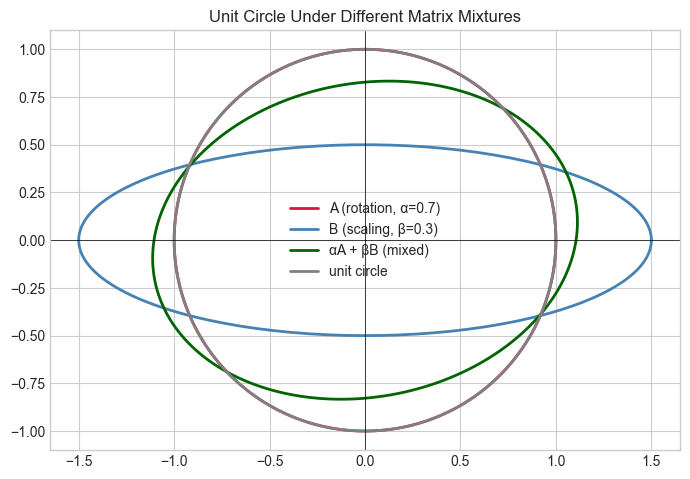

In [4]:
# --- Experiment: Matrix addition as superposition of effects ---
# Hypothesis: Applying A+B to a set of points produces the vector sum of A and B effects.
# Try changing: ALPHA, BETA — the mixing coefficients.
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

ALPHA = 0.7   # <-- modify: weight on A (rotation)
BETA  = 0.3   # <-- modify: weight on B (scaling)

# A: 30-degree rotation
theta = np.pi / 6
A = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])
# B: non-uniform scaling
B = np.array([[1.5, 0.0], [0.0, 0.5]])

# Mix
M = ALPHA * A + BETA * B

# Apply to unit circle
t = np.linspace(0, 2*np.pi, 200)
circle = np.row_stack([np.cos(t), np.sin(t)])

fig, ax = plt.subplots(figsize=(7, 7))
for mat, color, label in [(A, 'crimson', f'A (rotation, α={ALPHA})'),
                            (B, 'steelblue', f'B (scaling, β={BETA})'),
                            (M, 'darkgreen', f'αA + βB (mixed)'),
                            (np.eye(2), 'gray', 'unit circle')]:
    result = mat @ circle
    ax.plot(result[0], result[1], color=color, label=label, linewidth=2)

ax.set_aspect('equal')
ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
ax.legend(); ax.set_title('Unit Circle Under Different Matrix Mixtures')
plt.tight_layout(); plt.show()

---

## 7. Exercises

**Easy 1.** Compute A + B by hand: `A = [[1,2],[3,4]]`, `B = [[-1,0],[2,-3]]`. What is 2A - B?

**Easy 2.** Why can you not add a (3×4) matrix to a (4×3) matrix? What would you need to do first?

**Medium 1.** Write a function `linear_combo_matrices(matrices, coefficients)` that computes a weighted sum of a list of matrices. Use it to interpolate between a rotation matrix and a scaling matrix with α from 0 to 1 in 5 steps. Plot the unit circle under each interpolated matrix.

**Medium 2.** In a neural network, the forward pass is `Z = W @ X + b` where W is (m,n), X is (n, batch), and b is (m,). What is the shape of Z? Why does `b` broadcast correctly here? Write it out.

**Hard.** Prove that the set of all m×n matrices forms a vector space under matrix addition and scalar multiplication. Identify the zero vector, additive inverse, and verify all 8 axioms with short NumPy demonstrations.

---

## 8. Mini Project

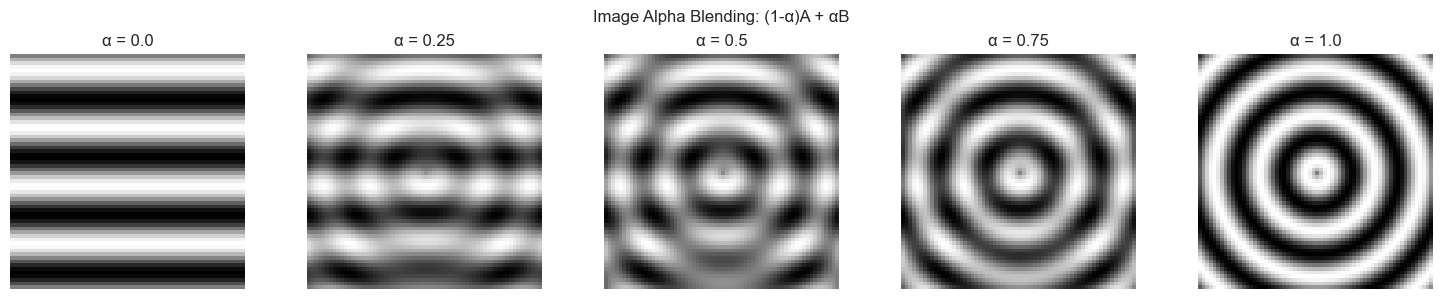

In [5]:
# --- Mini Project: Image blending via matrix addition ---
# Problem: Two 'images' (grayscale matrices) should be blended with
# a varying alpha parameter. This is the standard alpha-compositing operation.
# Task: implement blend(A, B, alpha) and show the result for alpha in [0, 0.25, 0.5, 0.75, 1.0]

import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

SIZE = 64
x = np.linspace(0, 4*np.pi, SIZE)
X, Y = np.meshgrid(x, x)

# Image A: horizontal stripes
img_A = (np.sin(Y * 2) + 1) / 2
# Image B: concentric circles
cx, cy = SIZE//2, SIZE//2
r = np.sqrt((np.arange(SIZE)[:, None] - cy)**2 + (np.arange(SIZE)[None, :] - cx)**2)
img_B = (np.sin(r * 0.5) + 1) / 2

def blend(A, B, alpha):
    """
    Alpha-blend two same-shape matrices.
    alpha=0 → pure A, alpha=1 → pure B.

    Args:
        A, B: 2D numpy arrays (same shape)
        alpha: float in [0, 1]

    Returns:
        2D numpy array
    """
    return (1 - alpha) * A + alpha * B   # pure matrix arithmetic

alphas = [0.0, 0.25, 0.5, 0.75, 1.0]
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for ax, alpha in zip(axes, alphas):
    blended = blend(img_A, img_B, alpha)
    ax.imshow(blended, cmap='gray', vmin=0, vmax=1)
    ax.set_title(f'α = {alpha}')
    ax.axis('off')

plt.suptitle('Image Alpha Blending: (1-α)A + αB', fontsize=12)
plt.tight_layout()
plt.show()

---

## 9. Chapter Summary & Connections

- Matrix addition is elementwise: `(A+B)[i,j] = A[i,j] + B[i,j]`. Shapes must match.
- `(A+B)v = Av + Bv` — adding transformation matrices adds their effects on vectors.
- NumPy broadcasting allows adding matrices with compatible (not necessarily identical) shapes.
- The bias term `b` in every neural network layer is added via broadcasting *(reappears in ch178 — Linear Layers in Deep Learning)*.

**Backward connection:** Matrix addition inherits all properties from vector addition *(ch125)* — matrices are just vectors stored in a 2D grid.

**Forward connections:**
- In ch154 (Matrix Multiplication), we encounter the non-trivial operation — composition, not just elementwise combination.
- In ch176 (Matrix Calculus Introduction), the gradient of a scalar-valued matrix function `f(A)` is itself a matrix of the same shape — added back to A in gradient descent updates.